In [18]:
# try to mount google colab
import os
try:
  from google.colab import drive
  drive.mount('/content/drive')
  cur_dir = '/content/drive/MyDrive/ws/prj/adv_ds_2310/Lab05_Models/ex02_pima_diabetes_classification/preprocessing'
except:
  cur_dir = '.'
  pass
cur_dir = os.path.abspath(cur_dir)
os.chdir(cur_dir)

print(f'cur_dir: {cur_dir} \n --> {os.path.abspath(".")}')

cur_dir: d:\CoSoTriTueNhanTao-2026\ai_practice_prj\lesson1\lab07_ml_models\pima_diabetes_classification\preprocessing 
 --> d:\CoSoTriTueNhanTao-2026\ai_practice_prj\lesson1\lab07_ml_models\pima_diabetes_classification\preprocessing


# Phân loại bệnh tiểu đường Pima
## 1. Định nghĩa vấn đề (Define Problem)
+ **Mô tả**: Dự đoán bệnh tiểu đường dựa trên các chỉ số y tế ở bộ dữ liệu Pima Indians.
+ **Dữ liệu vào**: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
+ **Kết quả**: Outcome (0/1)


## 2. Chuẩn bị vấn đề (Prepare Problem)
### 2.1. Khai báo thư viện (Load Libraries)

In [19]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings

%matplotlib inline
warnings.filterwarnings('ignore')

### 2.2. Tham số chương trình (Set Parameters)

In [20]:
# params
seed = 42

exps_dir = '../exps'
os.makedirs(exps_dir, exist_ok=True)
os.makedirs(f'{exps_dir}/data', exist_ok=True)

save_dir = f'{exps_dir}/feature1'
os.makedirs(save_dir, exist_ok=True)

### 2.3. Nạp dữ liệu (Load Dataset)

In [21]:
# Load dataset
data_path = '../data/diabetes.csv'
col_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df_org = pd.read_csv(data_path)
if 'Outcome' not in df_org.columns:
    df_org = pd.read_csv(data_path, header=None, names=col_names)

print(f'+ Shape: {df_org.shape}')
display.display(df_org.head())

+ Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 2.4. Chia dữ liệu thực nghiệm (Split Train/Test)

In [22]:
index_all = np.arange(len(df_org))
index_train, index_test = train_test_split(
    index_all, test_size=0.33, random_state=seed, stratify=df_org['Outcome']
 )

df_train = df_org.iloc[index_train].copy()
df_test = df_org.iloc[index_test].copy()

df_train.to_excel(f'{exps_dir}/data/train.xlsx', index=None)
df_test.to_excel(f'{exps_dir}/data/test.xlsx', index=None)
np.savez(f'{exps_dir}/data/idx.npz', id_train=index_train, id_test=index_test)

print(f'+ Train shape: {df_train.shape}')
print(f'+ Test shape : {df_test.shape}')

+ Train shape: (514, 9)
+ Test shape : (254, 9)


## 4. Tiền xử lý dữ liệu (Data Preprocessing)

### 4.1. Làm sạch dữ liệu (Data Cleaning)

#### Tạo bảng dữ liệu làm sạch và kiểm tra chất lượng dữ liệu

In [23]:
# Tạo bảng dữ liệu làm sạch từ dữ liệu gốc
df_train_clean = df_train.copy()
df_test_clean = df_test.copy()

print("Thông tin dữ liệu gốc:")
print(f"+ Train shape: {df_train_clean.shape}")
print(f"+ Test shape: {df_test_clean.shape}")

Thông tin dữ liệu gốc:
+ Train shape: (514, 9)
+ Test shape: (254, 9)


#### Xóa dữ liệu trùng nhau (Remove Duplicates)

In [24]:
# Kiểm tra dữ liệu trùng nhau
print("Số dòng trùng nhau trong train:")
print(df_train_clean[df_train_clean.duplicated(keep=False)].shape[0])
print("\nSố dòng trùng nhau trong test:")
print(df_test_clean[df_test_clean.duplicated(keep=False)].shape[0])

# Xóa dữ liệu trùng nhau (nếu có)
df_train_clean = df_train_clean.drop_duplicates(ignore_index=True)
df_test_clean = df_test_clean.drop_duplicates(ignore_index=True)

print(f"\nSau khi xóa duplicates:")
print(f"+ Train shape: {df_train_clean.shape}")
print(f"+ Test shape: {df_test_clean.shape}")

Số dòng trùng nhau trong train:
0

Số dòng trùng nhau trong test:
0

Sau khi xóa duplicates:
+ Train shape: (514, 9)
+ Test shape: (254, 9)


#### Xử lý giá trị rỗng, không hợp lệ (Handle Missing & Invalid Values)

In [25]:
# Kiểm tra giá trị NaN và NULL
print("Kiểm tra Null Value trong train:")
print(df_train_clean.isnull().sum())
print("\nKiểm tra Null Value trong test:")
print(df_test_clean.isnull().sum())

# Xử lý giá trị 0 phi lý ở các cột y tế
# Các cột y tế không nên có giá trị 0 theo ý nghĩa sinh học
medical_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 -> NaN
df_train_clean[medical_zero_cols] = df_train_clean[medical_zero_cols].replace(0, np.nan)
df_test_clean[medical_zero_cols] = df_test_clean[medical_zero_cols].replace(0, np.nan)

# Điền giá trị bằng median (được tính từ training set để tránh data leakage)
median_values = df_train_clean[medical_zero_cols].median()
df_train_clean[medical_zero_cols] = df_train_clean[medical_zero_cols].fillna(median_values)
df_test_clean[medical_zero_cols] = df_test_clean[medical_zero_cols].fillna(median_values)

print("\nGiá trị median dùng để fill:")
display.display(median_values)

print(f"\nSau khi xử lý giá trị 0/NaN:")
print(f"+ Train shape: {df_train_clean.shape}")
print(f"+ Test shape: {df_test_clean.shape}")

Kiểm tra Null Value trong train:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Kiểm tra Null Value trong test:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Giá trị median dùng để fill:


Glucose          116.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          126.0
BMI               32.4
dtype: float64


Sau khi xử lý giá trị 0/NaN:
+ Train shape: (514, 9)
+ Test shape: (254, 9)


In [26]:
# Kiểm tra số lượng giá trị 0 sau khi xử lý
print('+ Số lượng 0 trong các cột y tế (Train sau khi fill):')
display.display((df_train_clean[medical_zero_cols] == 0).sum())
print('+ Số lượng 0 trong các cột y tế (Test sau khi fill):')
display.display((df_test_clean[medical_zero_cols] == 0).sum())

+ Số lượng 0 trong các cột y tế (Train sau khi fill):


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

+ Số lượng 0 trong các cột y tế (Test sau khi fill):


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

### 4.2. Chuẩn hóa dữ liệu (Data Normalize)
Chuẩn hóa các tính chất để đưa về cùng một miền trị.
+ Min-Max Normalization: $z = \frac{x - \min(x)}{\max(x) - \min(x)}$
+ Standard Normalization: $z = \frac{x - \mu}{\sigma}$

**Lưu ý**: Thực hiện fit scaler trên tập train để đảm bảo nguyên tắc thực nghiệm và tránh rò rỉ dữ liệu (data leakage).

#### Min-Max Normalization

In [27]:
from sklearn.preprocessing import MinMaxScaler

scale_columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

# Min-Max Scaler
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(df_train_clean[scale_columns])

df_train_minmax = df_train_clean.copy()
df_test_minmax = df_test_clean.copy()
df_train_minmax[scale_columns] = minmax_scaler.transform(df_train_clean[scale_columns])
df_test_minmax[scale_columns] = minmax_scaler.transform(df_test_clean[scale_columns])

# Lưu scaler
joblib.dump(minmax_scaler, f'{save_dir}/minmax_scaler.joblib')
np.savez(f'{save_dir}/scale_columns.npz', scale_columns=scale_columns)

print("Min-Max Normalization:")
print(f"+ Train shape: {df_train_minmax.shape}")
print(f"+ Test shape: {df_test_minmax.shape}")
display.display(df_train_minmax.head())

Min-Max Normalization:
+ Train shape: (514, 9)
+ Test shape: (254, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.058824,0.446809,0.571429,0.773585,0.252747,0.423313,0.480178,0.333333,0
1,0.058824,0.219858,0.061224,0.660377,0.114011,0.752556,0.183519,0.083333,1
2,0.235294,0.595745,0.510204,0.415094,0.151099,0.192229,0.071269,0.316667,0
3,0.117647,0.170213,0.367347,0.283019,0.151099,0.194274,0.091759,0.066667,0
4,0.117647,0.347518,0.408163,0.528302,0.141484,0.251534,0.586192,0.216667,0


#### Standard Normalization

In [28]:
# Standard Normalization
standard_scaler = StandardScaler()
standard_scaler.fit(df_train_clean[scale_columns])

df_train_standard = df_train_clean.copy()
df_test_standard = df_test_clean.copy()
df_train_standard[scale_columns] = standard_scaler.transform(df_train_clean[scale_columns])
df_test_standard[scale_columns] = standard_scaler.transform(df_test_clean[scale_columns])

# Lưu scaler
joblib.dump(standard_scaler, f'{save_dir}/standard_scaler.joblib')

print("Standard Normalization:")
print(f"+ Train shape: {df_train_standard.shape}")
print(f"+ Test shape: {df_test_standard.shape}")
display.display(df_train_standard.head())

Standard Normalization:
+ Train shape: (514, 9)
+ Test shape: (254, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.860443,-0.039365,0.630746,2.303546,0.794689,0.922152,2.019564,0.663849,0
1,-0.860443,-1.102533,-3.458601,1.575887,-0.494263,3.300576,0.051445,-0.633231,1
2,0.031226,0.658340,0.140024,-0.000708,-0.149692,-0.747177,-0.693249,0.577377,0
3,-0.563220,-1.335101,-1.004993,-0.849643,-0.149692,-0.732404,-0.557313,-0.719703,0
4,-0.563220,-0.504501,-0.677845,0.726951,-0.239025,-0.318765,2.722886,0.058545,0


In [29]:
# scale_columns và standard_scaler đã được lưu ở trên
# Kiểm tra lại
print("Scale columns:")
print(scale_columns)
print("\nStandard Scaler info:")
print(joblib.load(f'{save_dir}/standard_scaler.joblib').__dict__.keys())

Scale columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Standard Scaler info:
dict_keys(['with_mean', 'with_std', 'copy', 'feature_names_in_', 'n_features_in_', 'n_samples_seen_', 'mean_', 'var_', 'scale_'])


### 4.4. Chọn Feature quan trọng (Feature Selection)
Sử dụng SelectKBest với f_classif để chọn 5 features có score cao nhất.
Fit trên X_train_bal, y_train_bal (sau SMOTE) và transform cả train và test.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE

# Chuẩn bị dữ liệu sau standard scaling
X_train_scaled = df_train_standard[scale_columns].values
y_train = df_train_standard['Outcome'].values

# Feature Selection sử dụng SelectKBest (TRƯỚC KHI SMOTE)
k_features = 5
selector = SelectKBest(score_func=f_classif, k=k_features)

# Fit trên dữ liệu train gốc rỗng chưa SMOTE
selector.fit(X_train_scaled, y_train)

# Transform cả train và test
X_train_selected = selector.transform(X_train_scaled)
X_test_scaled = df_test_standard[scale_columns].values
X_test_selected = selector.transform(X_test_scaled)

print(f"Chọn {k_features} features quan trọng nhất")
print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_test_selected shape: {X_test_selected.shape}")

# Lấy tên và score của các features
feature_scores = selector.scores_
selected_indices = selector.get_support(indices=True)
selected_features = [scale_columns[i] for i in selected_indices]

print(f"\nTên 5 features được chọn: {selected_features}")
print(f"Scores: {feature_scores[selected_indices].round(2)}")

# Áp dụng SMOTE SAU KHI FEATURE SELECTION
print("\nTrước SMOTE (đã qua Feature Selection):")
print(f"  X_train_selected shape: {X_train_selected.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Class distribution: {np.bincount(y_train.astype(int))}")

smote = SMOTE(random_state=seed)
X_train_bal, y_train_bal = smote.fit_resample(X_train_selected, y_train)

print(f"\nSau SMOTE:")
print(f"  X_train_bal shape: {X_train_bal.shape}")
print(f"  y_train_bal shape: {y_train_bal.shape}")
print(f"  Class distribution: {np.bincount(y_train_bal.astype(int))}")

# Lưu SMOTE result
np.savez(f'{save_dir}/X_train_bal.npz', X_train=X_train_bal, y_train=y_train_bal)


Chọn 5 features quan trọng nhất
X_train_selected shape: (670, 5)
X_test_selected shape: (254, 5)

Tên 5 features được chọn: ['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'Age']
Scores: [ 36.67 230.67  51.84  82.42  34.9 ]


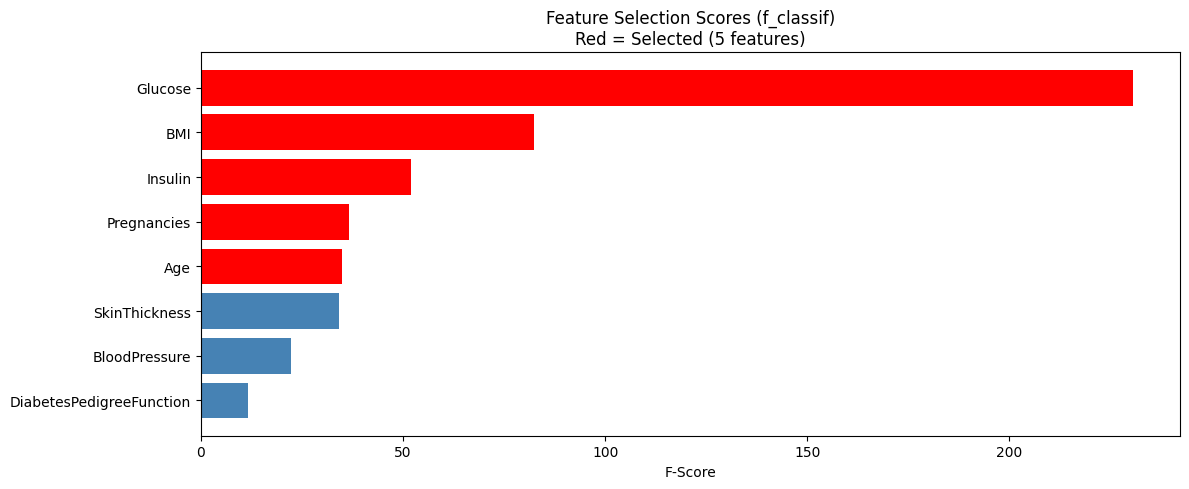

In [32]:
# Vẽ biểu đồ Feature Scores
fig, ax = plt.subplots(figsize=(12, 5))

# Sắp xếp features theo score giảm dần
sorted_idx = np.argsort(feature_scores)[::-1]
sorted_features = [scale_columns[i] for i in sorted_idx]
sorted_scores = feature_scores[sorted_idx]

# Highlight 5 features được chọn
colors = ['red' if i in selected_indices else 'steelblue' for i in sorted_idx]

ax.barh(range(len(sorted_features)), sorted_scores, color=colors)
ax.set_yticks(range(len(sorted_features)))
ax.set_yticklabels(sorted_features)
ax.set_xlabel('F-Score')
ax.set_title('Feature Selection Scores (f_classif)\nRed = Selected (5 features)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Lưu selector và selected features
joblib.dump(selector, f'{save_dir}/selector_kbest.joblib')
np.savez(f'{save_dir}/selected_features.npz', selected_features=selected_features)

### 5. Lưu dữ liệu Features
+ Chuyển đổi dữ liệu sang dạng numpy với phần Input (X_data), Output (y_data)
+ Lưu tất cả thông tin để chuẩn bị chạy thuật toán

In [ ]:
# Train Data - Standard + Feature Selected (chưa qua SMOTE để dùng cho Cross-Validation Pipeline)
np.savez(f'{save_dir}/feat_standard.npz', x_train=X_train_selected, y_train=y_train)

# Lưu thêm chuỗi SMOTE để sử dụng cho train Final Model ở file modeling (nếu cần)
np.savez(f'{save_dir}/feat_standard_bal.npz', x_train=X_train_bal, y_train=y_train_bal)

df_train_standard.to_excel(f'{save_dir}/df_standard.xlsx', index=False)

print("Train (Standard + Feature Selected, BEFORE SMOTE):")
print(f'+ x_train shape (5 features): {X_train_selected.shape}')
print(f'+ y_train shape: {y_train.shape}')
print(f'+ y_train sample: {y_train[:5]}')


Train (Standard + SMOTE + Feature Selected):
+ x_train shape (5 features): (670, 5)
+ y_train shape (balanced): (670,)
+ y_train sample: [0 1 0 0 0]


In [34]:
# Train Data - MinMax (lưu để dùng nếu cần so sánh, nhưng chủ yếu dùng Standard)
x_train_minmax = df_train_minmax.values[:, :-1]
y_train_minmax = df_train_minmax.values[:, -1]
np.savez(f'{save_dir}/feat_minmax.npz', x_train=x_train_minmax, y_train=y_train_minmax)
df_train_minmax.to_excel(f'{save_dir}/df_minmax.xlsx', index=False)

print("Train (MinMax - for reference):")
print(f'+ x_train shape: {x_train_minmax.shape}')
print(f'+ y_train shape: {y_train_minmax.shape}')

Train (MinMax - for reference):
+ x_train shape: (514, 8)
+ y_train shape: (514,)


In [35]:
# Test Data - Standard + Feature Selected
# Sử dụng X_test_selected (5 features) - KHÔNG áp dụng SMOTE trên test
y_test = df_test_standard['Outcome'].values
np.savez(f'{save_dir}/feat_standard_test.npz', x_test=X_test_selected, y_test=y_test)
df_test_standard.to_excel(f'{save_dir}/df_standard_test.xlsx', index=False)

print("Test (Standard + Feature Selected - No SMOTE):")
print(f'+ x_test shape (5 features): {X_test_selected.shape}')
print(f'+ y_test shape: {y_test.shape}')
print(f'+ y_test sample: {y_test[:5]}')

Test (Standard + Feature Selected - No SMOTE):
+ x_test shape (5 features): (254, 5)
+ y_test shape: (254,)
+ y_test sample: [0 1 1 0 0]


In [36]:
# Test Data - MinMax (lưu để dùng nếu cần so sánh, nhưng chủ yếu dùng Standard)
x_test_minmax = df_test_minmax.values[:, :-1]
y_test_minmax = df_test_minmax.values[:, -1]
np.savez(f'{save_dir}/feat_minmax_test.npz', x_test=x_test_minmax, y_test=y_test_minmax)
df_test_minmax.to_excel(f'{save_dir}/df_minmax_test.xlsx', index=False)

print("Test (MinMax - for reference):")
print(f'+ x_test shape: {x_test_minmax.shape}')
print(f'+ y_test shape: {y_test_minmax.shape}')

Test (MinMax - for reference):
+ x_test shape: (254, 8)
+ y_test shape: (254,)


# Kết thúc

In [37]:
!rm $cur_dir/preprocessing_pima.html
!jupyter nbconvert $cur_dir/preprocessing_pima.ipynb --to html

'rm' is not recognized as an internal or external command,
operable program or batch file.
[NbConvertApp] Converting notebook d:\CoSoTriTueNhanTao-2026\ai_practice_prj\lesson1\lab07_ml_models\pima_diabetes_classification\preprocessing/preprocessing_pima.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 392515 bytes to d:\CoSoTriTueNhanTao-2026\ai_practice_prj\lesson1\lab07_ml_models\pima_diabetes_classification\preprocessing\preprocessing_pima.html
